In [3]:
# Install RDKit (chemical informatics library)
!pip install rdkit

# Import everything we need
import pandas as pd         # for handling data
import numpy as np          # for math operations
import matplotlib.pyplot as plt   # for plotting graphs
from sklearn.linear_model import LinearRegression  #ML model
from sklearn.model_selection import train_test_split   # split data
from sklearn.metrics import mean_absolute_error, r2_score   # check accuracy

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [5]:
# Load a free chemical boiling point dataset
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"

df = pd.read_csv(url)

# Look at the first 5 rows
print(df.head())
print("\nShape:", df.shape)   #how many rows and columns
print("\nColumns:", df.columns.tolist())   # column names



  Compound ID  ESOL predicted log solubility in mols per litre  \
0   Amigdalin                                           -0.974   
1    Fenfuram                                           -2.885   
2      citral                                           -2.579   
3      Picene                                           -6.618   
4   Thiophene                                           -2.232   

   Minimum Degree  Molecular Weight  Number of H-Bond Donors  Number of Rings  \
0               1           457.432                        7                3   
1               1           201.225                        1                2   
2               1           152.237                        0                0   
3               2           278.354                        0                5   
4               2            84.143                        0                1   

   Number of Rotatable Bonds  Polar Surface Area  \
0                          7              202.32   
1           

Missing values:
df.isnull().sum()

Basic Statistics:
       ESOL predicted log solubility in mols per litre  Minimum Degree  \
count                                      1128.000000     1128.000000   
mean                                         -2.988192        1.058511   
std                                           1.683220        0.238560   
min                                          -9.702000        0.000000   
25%                                          -3.948250        1.000000   
50%                                          -2.870000        1.000000   
75%                                          -1.843750        1.000000   
max                                           1.091000        2.000000   

       Molecular Weight  Number of H-Bond Donors  Number of Rings  \
count       1128.000000              1128.000000      1128.000000   
mean         203.937074                 0.701241         1.390957   
std          102.738077                 1.089727         1.318286   
min 

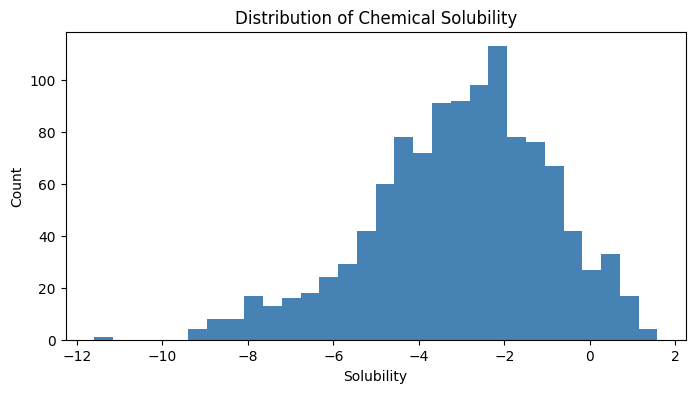

In [7]:
# Check missing values
print("Missing values:")
print("df.isnull().sum()")

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Plot distribution of what we want to predict
plt.figure(figsize=(8, 4))
plt.hist(df['measured log solubility in mols per litre'], bins=30, color='steelblue')
plt.xlabel('Solubility')
plt.ylabel('Count')
plt.title('Distribution of Chemical Solubility')
plt.show()

In [10]:
# Choose input features (column that help predict solubility)
feature_columns =[
    'Molecular Weight',
    'Number of H-Bond Donors',
    'Number of Rings',
    'Number of Rotatable Bonds',
    'Polar Surface Area'
]

# Check if these columns exist in dataset
print(df.columns.tolist())

# X = inputs, y = what we want to predict
X = df[feature_columns]
y = df['measured log solubility in mols per litre']

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']
Input Shape: (1128, 5)
Output Shape: (1128,)


In [11]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% goes to testing
    random_state=42    # so results are reproducible
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 902
Testing samples: 226


In [12]:
# Create the model
model = LinearRegression()

# Train it on training data
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
# Make prediction on test data
y_predicted = model.predict(X_test)

# Calculate accuracy metrics
mae = mean_absolute_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

print(f"Mean Absolute Error: {mae:.3f}")
print(f"R_squared score: {r2:.3f}")

# R_squared closer to 1.0 = better model
# R_squared of 0.7 means model explains 70% of the variation

Mean Absolute Error: 0.904
R_squared score: 0.689


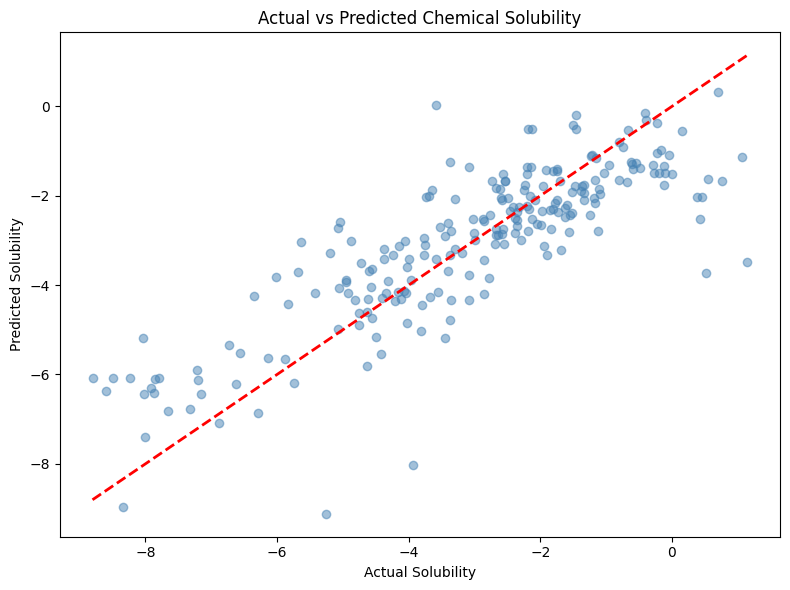

In [15]:
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predicted, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)        # perfect prediction line

plt.xlabel('Actual Solubility')
plt.ylabel('Predicted Solubility')
plt.title('Actual vs Predicted Chemical Solubility')
plt.tight_layout()
plt.show()

In [18]:
# Predict solubility for a new, unseen chemical
new_chemical = pd.DataFrame({
    'Molecular Weight': [180.16],
    'Number of H-Bond Donors': [5],
    'Number of Rings': [1],
    'Number of Rotatable Bonds': [1],
    'Polar Surface Area': [110.4]
})

prediction = model.predict(new_chemical)
print(f"Predicted solubility: {prediction[0]:.3f} mol/L")

Predicted solubility: 0.457 mol/L


In [19]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_predicted
})
results.to_csv('predictions.csv', index=False)
print("Results saved!")

Results saved!
